In [30]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'

cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
cell_classifications['SC_x'] = np.abs(cell_classifications['SC_x'])
cell_classifications


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,grid_module,ramp_cell,speed_modulated,vr_outbound_sign,vr_homebound_sign,vr_spatial_information,vr_spatial_information_sig,shank_id,head_direction_cell,head_direction_classified_by
0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,NaN,...,NaN,False,False,NaN,NaN,0.210157,True,0.0,True,OF1
1,103,ENTm1,-0.140560,58.812343,78.416458,15.687386,1.5,2,False,NaN,...,NaN,True,True,-,+,0.075680,True,1.0,True,both
2,400,ENTm3,-0.186061,36.455207,48.606943,15.708574,1.5,2,False,NaN,...,NaN,False,False,NaN,NaN,0.000109,False,3.0,False,neither
3,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,NaN,...,NaN,False,False,NaN,NaN,0.005485,True,3.0,False,neither
4,37,ENTm1,-0.716572,26.094122,34.792162,10.002436,1.5,2,False,NaN,...,NaN,True,False,-,+,0.091285,True,0.0,False,neither
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8194,546,ENTm5,-0.418281,22.700455,30.267273,50.461543,1.5,7,False,NaN,...,NaN,False,False,NaN,NaN,0.058699,True,3.0,False,neither
8195,548,ENTm5,-0.371531,30.229735,40.306313,20.336845,1.5,7,False,NaN,...,NaN,False,False,NaN,NaN,0.054462,True,3.0,False,neither
8196,550,ENTm5,-0.111145,18.568656,24.758209,4.706601,1.5,7,False,NaN,...,NaN,False,False,NaN,NaN,0.064190,True,3.0,False,neither
8197,553,ENTm5,0.745899,50.170017,66.893356,55.679758,1.5,7,True,NaN,...,NaN,False,False,NaN,NaN,0.049365,True,3.0,True,OF2


In [31]:
mouse = 25
day = 25

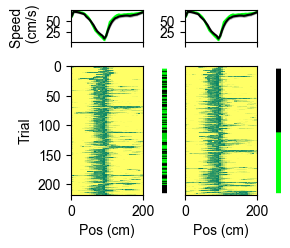

In [32]:
# --- Compute everything for both sort=False and sort=True ---
def get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort, trial_cat_priority=None):
    trial_numbers = np.array(beh['trial_number'])
    position = np.array(beh['P'])
    speed = np.array(beh['S'])
    stop_mask = speed < 3

    trial_numbers = trial_numbers[:len(stop_mask)]
    position = position[:len(stop_mask)]
    speed = speed[:len(stop_mask)]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)

    trial_df = beh['trials'][:int(last_ephys_bin/(tl/bs))]
    if sort:
        sorted_cats = trial_df.groupby(by=['context', 'type', 'performance'])
        if trial_cat_priority is not None:
            sorted_cats = sort_dict_by_priority(sorted_cats, trial_cat_priority)
        sorted_trial_indices = []
        for cat_indices in sorted_cats.values():
            sorted_trial_indices.extend(cat_indices.tolist())
        trial_order = sorted_trial_indices
    else:
        trial_order = trial_df.index.tolist()

    speed_matrix = np.full((len(trial_order), n_pos_bins), np.nan)
    trial_type_colors = []
    for i, ti in enumerate(trial_order):
        trial_num = trial_df['number'][ti]
        mask = (trial_numbers == trial_num)
        pos_trial = position[mask]
        speed_trial = speed[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed_profile = bin_sums / bin_counts
        speed_matrix[i, :] = speed_profile

        trial_type = trial_df['type'][ti]
        if isinstance(trial_type, str):
            color = get_color_for_group(('rz1', trial_type, 'hit')) if 'get_color_for_group' in globals() else 'grey'
        else:
            color = 'grey'
        trial_type_colors.append(color)
    return speed_matrix, trial_type_colors, trial_order, pos_bins

def sem_nan(a, axis=0):
    # sample standard deviation (ddof=1) / sqrt(n) ignoring NaNs, returns NaN if n<=1
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = np.where(n > 1, std / np.sqrt(n), np.nan)
    return sem

def trial_type_stats_from_speed_matrix(beh, last_ephys_bin, tl, bs, speed_matrix, trial_order):
    trial_df = beh['trials'][:int(last_ephys_bin/(tl/bs))]
    # trial_order contains indices into trial_df
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]

    pos_bins = np.linspace(0, tl, int(tl/5) + 1)
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    unique_types = [t for t in np.unique(np.array(trial_types_order)) if str(t) != 'nan']
    type_means = {}
    type_sems = {}
    for t in unique_types:
        rows = [i for i, tt in enumerate(trial_types_order) if tt == t]
        if len(rows) == 0:
            continue
        data = speed_matrix[rows, :]  # shape (n_trials_of_type, n_pos_bins)
        type_means[t] = np.nanmean(data, axis=0)
        type_sems[t] = sem_nan(data, axis=0)

    overall_mean = np.nanmean(speed_matrix, axis=0)
    overall_sem = sem_nan(speed_matrix, axis=0)

    return pos_centers, unique_types, type_means, type_sems, overall_mean, overall_sem



# --- Prepare data for both sort=False and sort=True ---
_, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day)

speed_matrix_unsorted, trial_type_colors_unsorted, trial_order_unsorted, pos_bins = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False)
speed_matrix_sorted, trial_type_colors_sorted, trial_order_sorted, _ = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=True)

pos_centers_u, types_u, type_means_u, type_sems_u, overall_mean_u, overall_sem_u = trial_type_stats_from_speed_matrix(
    beh, last_ephys_bin, tl, bs, speed_matrix_unsorted, trial_order_unsorted
)

# --- Plot 4 columns: heatmap (unsorted), colors (unsorted), heatmap (sorted), colors (sorted) ---
fig, axes = plt.subplots(
    nrows=2, ncols=4, sharex='col', sharey=False,
    figsize=(rm_figsize[0]*3, rm_figsize[1]*1.7),
    gridspec_kw={'height_ratios': [0.25, 1], 'width_ratios': [20, 1, 20, 1]}
)

# 1st column: heatmap (unsorted)
ax = axes[1,0]
mesh = ax.pcolormesh(
    pos_bins, np.arange(len(trial_order_unsorted)+1),
    np.nan_to_num(speed_matrix_unsorted, nan=0),
    cmap='summer', shading='auto', vmin=0, vmax=60, 
    rasterized=True
)
ax.set_xlabel('Pos (cm)')
ax.set_ylabel('Trial')
ax.set_xlim(0, tl)
ax.set_ylim(0, len(trial_order_unsorted))
ax.invert_yaxis()
ax.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
yticks = np.arange(0.5, len(trial_order_unsorted)+0.5, 50)
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(i)) for i in np.arange(0, len(trial_order_unsorted), 50)])

# 2nd column: trial colors (unsorted)
ax_color = axes[1,1]
for i, color in enumerate(trial_type_colors_unsorted):
    ax_color.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color.set_xlim(-0.5, 0.5)
ax_color.set_xticks([])
ax_color.set_yticks([])
ax_color.set_frame_on(False)
ax_color.invert_yaxis()

# 3rd column: heatmap (sorted)
ax2 = axes[1,2]
mesh2 = ax2.pcolormesh(
    pos_bins, np.arange(len(trial_order_sorted)+1),
    np.nan_to_num(speed_matrix_sorted, nan=0),
    cmap='summer', shading='auto', vmin=0, vmax=60,
    rasterized=True
)
ax2.set_xlabel('Pos (cm)')
ax2.set_xlim(0, tl)
ax2.set_ylim(0, len(trial_order_sorted))
ax2.invert_yaxis()
ax2.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
ax2.set_yticks([])
ax2.set_yticklabels([])

# 4th column: trial colors (sorted)
ax_color2 = axes[1,3]
for i, color in enumerate(trial_type_colors_sorted):
    ax_color2.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color2.set_xlim(-0.5, 0.5)
ax_color2.set_xticks([])
ax_color2.set_yticks([])
ax_color2.set_frame_on(False)

ax_avg = axes[0,0]
for t in types_u:
    ax_avg.plot(pos_centers_u, type_means_u[t], color=get_color_for_group(('rz1', t, 'hit')))
    ax_avg.fill_between(pos_centers_u, type_means_u[t] - type_sems_u[t], type_means_u[t] + type_sems_u[t], 
                        color=get_color_for_group(('rz1', t, 'hit')), alpha=0.25)


ax_avg = axes[0,2]
for t in types_u:
    ax_avg.plot(pos_centers_u, type_means_u[t], color=get_color_for_group(('rz1', t, 'hit')))
    ax_avg.fill_between(pos_centers_u, type_means_u[t] - type_sems_u[t], type_means_u[t] + type_sems_u[t], 
                        color=get_color_for_group(('rz1', t, 'hit')), alpha=0.25)

'''
# Add a single horizontal colorbar at the top, with ticks above
cbar_ax = fig.add_axes([0.25, 0.96, 0.5, 0.025])  # [left, bottom, width, height] in figure coordinates
cb = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0, 60])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')
'''
axes[0,3].axis('off')
axes[0,1].axis('off')
axes[0,0].set_ylabel('Speed \n (cm/s)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_7_behaviour/behaviour_heatmaps_mouse{mouse}_day{day}.pdf', dpi=300)
plt.show()


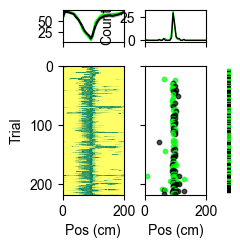

In [33]:
# --- Prepare data for both sort=False and sort=True ---
_, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day)

speed_matrix_unsorted, trial_type_colors_unsorted, trial_order_unsorted, pos_bins = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False)
speed_matrix_sorted, trial_type_colors_sorted, trial_order_sorted, _ = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=True)

pos_centers_u, types_u, type_means_u, type_sems_u, overall_mean_u, overall_sem_u = trial_type_stats_from_speed_matrix(
    beh, last_ephys_bin, tl, bs, speed_matrix_unsorted, trial_order_unsorted
)

fig, axes = plt.subplots(
    nrows=2, ncols=3, sharex='col', sharey=False,
    figsize=(rm_figsize[0]*2.5, rm_figsize[1]*1.7),
    gridspec_kw={'height_ratios': [0.25, 1], 'width_ratios': [20, 20, 1]}
)

# 1st column: heatmap (unsorted)
ax = axes[1,0]
mesh = ax.pcolormesh(
    pos_bins, np.arange(len(trial_order_unsorted)+1),
    np.nan_to_num(speed_matrix_unsorted, nan=0),
    cmap='summer', shading='auto', vmin=0, vmax=60, 
    rasterized=True
)
ax.set_xlabel('Pos (cm)')
ax.set_ylabel('Trial')
ax.set_xlim(0, tl)
ax.set_ylim(0, len(trial_order_unsorted))
ax.invert_yaxis()
ax.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
yticks = np.arange(0.5, len(trial_order_unsorted)+0.5, 100)
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(i)) for i in np.arange(0, len(trial_order_unsorted), 100)])

# 1st row, 2nd column: line histogram of stop locations by color
ax_hist = axes[0,1]
bin_edges = np.arange(0, 201, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
color_to_stops = {}

for trial_idx in range(speed_matrix_unsorted.shape[0]):
    stops = np.where(speed_matrix_unsorted[trial_idx, :] < 3)[0]
    if len(stops) > 0:
        stop_pos = (pos_bins[:-1] + pos_bins[1:]) / 2
        color = trial_type_colors_unsorted[trial_idx]
        if color not in color_to_stops:
            color_to_stops[color] = []
        color_to_stops[color].extend(stop_pos[stops])

for color, stops in color_to_stops.items():
    hist, _ = np.histogram(stops, bins=bin_edges)
    ax_hist.plot(bin_centers, hist, color=color, label=str(color), linewidth=1)
ax_hist.set_xlim(0, 200)
ax_hist.set_ylabel('Count')

# 2nd column, second row: scatter plot of stop locations (speed < 3)
ax_stop = axes[1,1]
for trial_idx in range(speed_matrix_unsorted.shape[0]):
    stops = np.where(speed_matrix_unsorted[trial_idx, :] < 3)[0]
    if len(stops) > 0:
        stop_pos = (pos_bins[:-1] + pos_bins[1:]) / 2
        ax_stop.scatter(stop_pos[stops], [trial_idx+0.5]*len(stops), color=trial_type_colors_unsorted[trial_idx], s=10, alpha=0.7)
ax_stop.set_xlim(0, tl)
ax_stop.set_ylim(0, len(trial_order_unsorted))
ax_stop.invert_yaxis()
ax_stop.set_xlabel('Pos (cm)')
ax_stop.set_yticks(yticks)
ax_stop.set_yticklabels([])

# 2nd column: trial colors (unsorted)
ax_color = axes[1,2]
for i, color in enumerate(trial_type_colors_unsorted):
    ax_color.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color.set_xlim(-0.5, 0.5)
ax_color.set_xticks([])
ax_color.set_yticks([])
ax_color.set_frame_on(False)
ax_color.invert_yaxis()

ax_avg = axes[0,0]
for t in types_u:
    ax_avg.plot(pos_centers_u, type_means_u[t], color=get_color_for_group(('rz1', t, 'hit')))
    ax_avg.fill_between(pos_centers_u, type_means_u[t] - type_sems_u[t], type_means_u[t] + type_sems_u[t], 
                        color=get_color_for_group(('rz1', t, 'hit')), alpha=0.25)

axes[0,2].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_7_behaviour/behaviour_heatmaps_mouse{mouse}_day{day}.pdf', dpi=300)
plt.show()

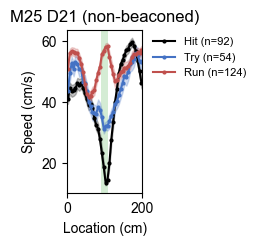

In [34]:
# --- Speed vs position by trial performance (Hit / Try / Run), non-beaconed trials ---
# Example session chosen by surveying all mice/days for the best-balanced non-beaconed
# hit/try/run counts (highest minimum count across the three categories):
#   M25 D21: hit=92, try=54, run=124 (min=54)  <- used below
#   Runner-up alternatives: M27 D20 (56/45/180), M28 D7 (59/44/41, most evenly balanced)
# Color scheme matches the reference figure: Hit=black, Try=blue, Run=red.
example_mouse, example_day = 25, 21
example_trial_type = 'nb'

def compute_speed_by_performance(beh_d, trial_type, tl, bs):
    trial_numbers_raw = np.array(beh_d['trial_number'])
    position_raw = np.array(beh_d['P'])
    speed_raw = np.array(beh_d['S'])
    n = min(len(trial_numbers_raw), len(position_raw), len(speed_raw))
    trial_numbers_raw = trial_numbers_raw[:n]
    position_raw = position_raw[:n]
    speed_raw = speed_raw[:n]

    trials_of_type = beh_d['trials'][beh_d['trials']['type'] == trial_type]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    perf_profiles = {}
    for idx in trials_of_type.index:
        perf = trials_of_type['performance'][idx]
        if perf not in ('hit', 'try', 'run'):
            continue
        trial_num = trials_of_type['number'][idx]
        mask = trial_numbers_raw == trial_num
        pos_trial = position_raw[mask]
        speed_trial = speed_raw[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            profile = bin_sums / bin_counts
        perf_profiles.setdefault(perf, []).append(profile)

    perf_stats = {}
    for perf, profiles in perf_profiles.items():
        arr = np.array(profiles)
        perf_stats[perf] = dict(mean=np.nanmean(arr, axis=0), sem=sem_nan(arr, axis=0), n=arr.shape[0])
    return pos_centers, perf_stats

perf_colors = {'hit': 'black', 'try': '#4472C4', 'run': '#C0504D'}
perf_labels = {'hit': 'Hit', 'try': 'Try', 'run': 'Run'}

beh_example = nap.load_file(
    f"{source_path}M{example_mouse}/D{example_day:02}/VR/sub-{example_mouse}_day-{example_day:02}_ses-VR_beh.nwb"
)
pos_centers, perf_stats = compute_speed_by_performance(beh_example, example_trial_type, tl, bs)

fig, ax = plt.subplots(figsize=(rm_figsize[0]*2.6, rm_figsize[1]*1.6))
ax.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='tab:green')
for perf in ('hit', 'try', 'run'):
    if perf not in perf_stats:
        continue
    st = perf_stats[perf]
    color = perf_colors[perf]
    ax.plot(pos_centers, st['mean'], color=color, linewidth=1.5, marker='o', markersize=2,
            label=f"{perf_labels[perf]} (n={st['n']})")
    ax.fill_between(pos_centers, st['mean'] - st['sem'], st['mean'] + st['sem'], color=color, alpha=0.25)
ax.set_xlabel('Location (cm)')
ax.set_ylabel('Speed (cm/s)')
ax.set_xlim(0, tl)
ax.set_title(f'M{example_mouse} D{example_day} (non-beaconed)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02), frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_7_behaviour/behaviour_speed_by_performance_mouse{example_mouse}_day{example_day}.pdf',
    dpi=300, bbox_inches='tight',
)
plt.savefig(
    f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_7_behaviour/behaviour_speed_by_performance_mouse{example_mouse}_day{example_day}.png',
    dpi=500, bbox_inches='tight',
)
plt.show()

--- Mouse 20 ---


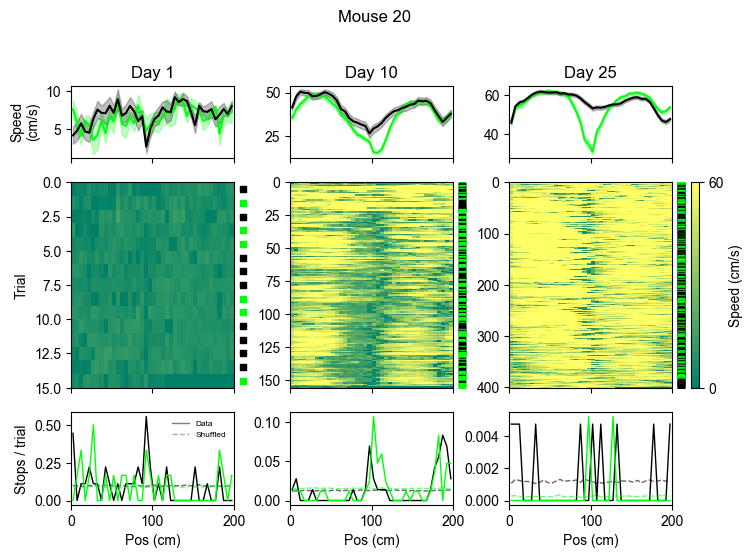

--- Mouse 21 ---


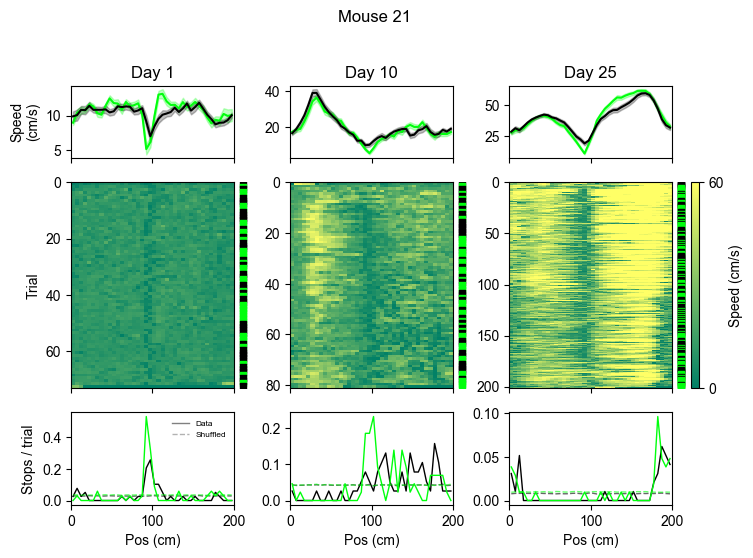

--- Mouse 22 ---


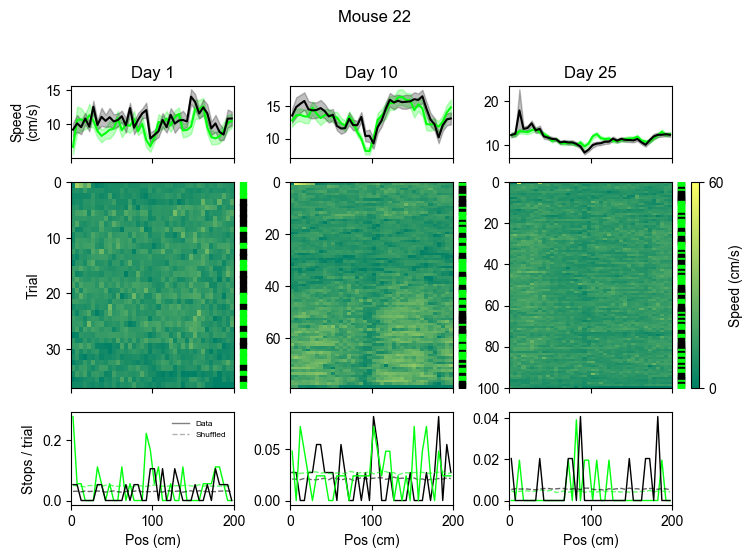

--- Mouse 25 ---


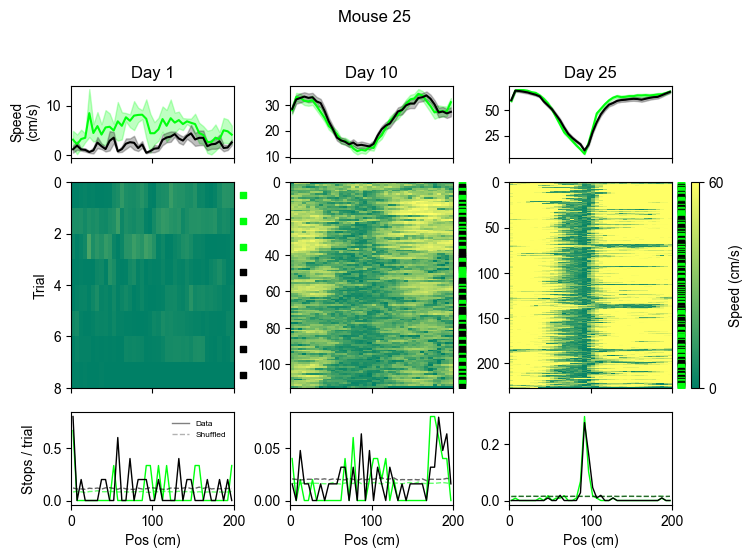

--- Mouse 26 ---
  M26 Day 25: missing, falling back to latest available Day 19


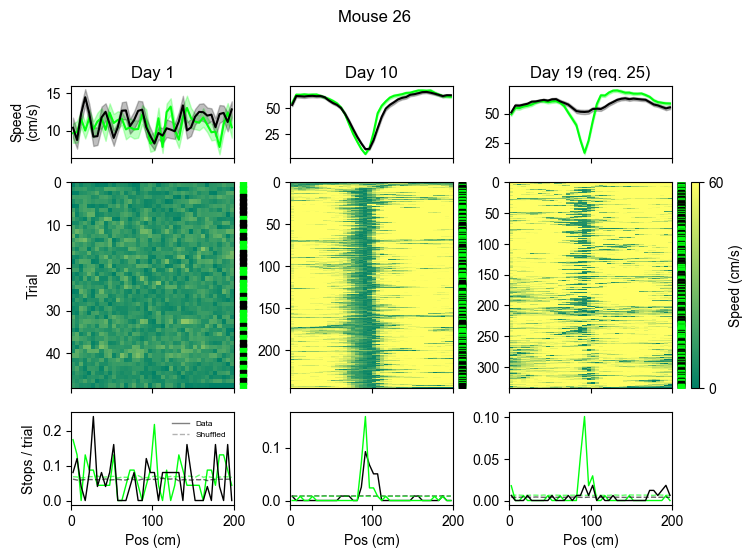

--- Mouse 27 ---
  M27 Day 25: missing, falling back to latest available Day 26


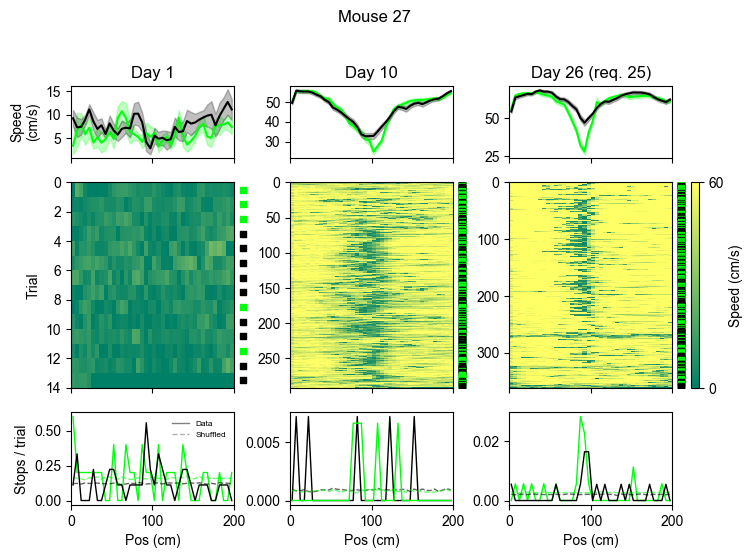

--- Mouse 28 ---


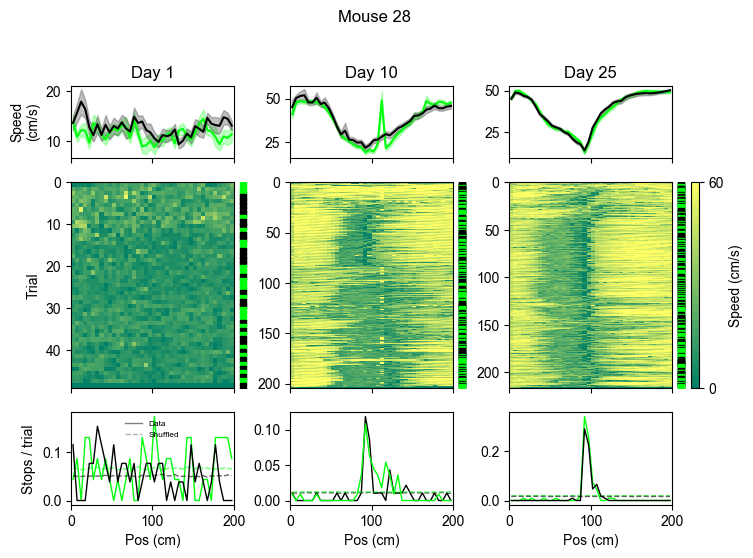

--- Mouse 29 ---


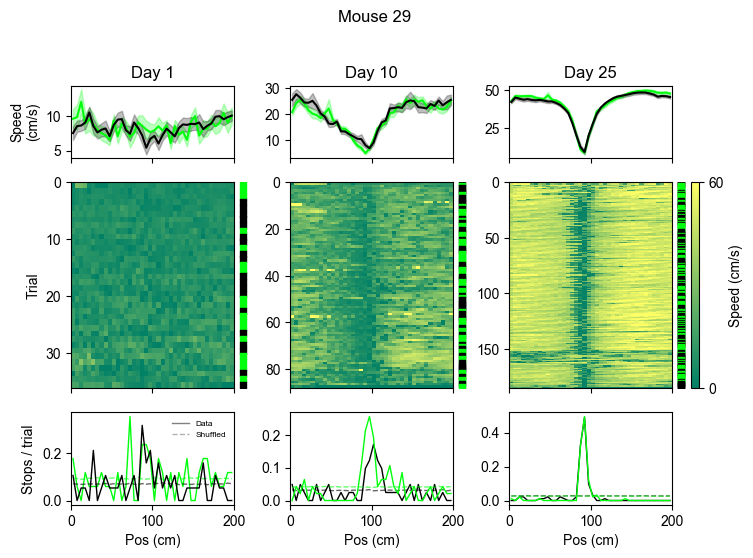

In [35]:
# --- Speed & stopping behaviour across training days 1, 10, 25, for each mouse ---
# 3 rows x 9 cols: for each day -- main col (20 wide), trial-type raster col (1 wide) -- then
# a spacer (4 wide) between days, and a speed colorbar col (1 wide) at the very end. wspace is
# kept small so raster sits close to its heatmap; day-to-day separation comes from spacer width.
# Row 0: speed by trial type. Row 1: speed as a fn of trial x position (+ trial-type raster).
# Row 2: stops/trial (+ shuffled baseline).
# If the last requested day (25) isn't available for a mouse, falls back to that mouse's latest available VR day.
from matplotlib.lines import Line2D

days_to_show = [1, 10, 25]
n_shuffles = 1000
mice_to_plot = [20, 21, 22, 25, 26, 27, 28, 29]  # same cohort as df_hits below

def load_raw_beh(m, d, vr_type='VR'):
    vr_folder = f'{source_path}M{m}/D{d:02}/{vr_type}/'
    beh_path = vr_folder + f"sub-{m}_day-{d:02}_ses-{vr_type}_beh.nwb"
    return nap.load_file(beh_path)

def available_vr_days(m, vr_type='VR'):
    files = sorted(glob.glob(f'{source_path}M{m}/D*/{vr_type}/sub-{m}_day-*_ses-{vr_type}_beh.nwb'))
    days = [int(os.path.basename(f).split('day-')[1].split('_')[0]) for f in files]
    return sorted(set(days))

def resolve_day(m, requested_day, used_days, allow_fallback):
    try:
        return requested_day, load_raw_beh(m, requested_day)
    except Exception as e:
        if not allow_fallback:
            print(f"  M{m} Day {requested_day}: missing ({e})")
            return None, None
        candidates = [d for d in available_vr_days(m) if d not in used_days]
        if not candidates:
            print(f"  M{m} Day {requested_day}: missing, no fallback day available")
            return None, None
        fallback_day = candidates[-1]
        print(f"  M{m} Day {requested_day}: missing, falling back to latest available Day {fallback_day}")
        try:
            return fallback_day, load_raw_beh(m, fallback_day)
        except Exception as e2:
            print(f"  M{m}: fallback Day {fallback_day} also failed ({e2})")
            return None, None

def stop_onsets(speed_row, threshold=3):
    # Only the first bin of each contiguous below-threshold run counts as a stop
    # (i.e. a bout onset) -- consecutive below-threshold bins in the same bout,
    # and re-crossings while still below threshold, are not re-counted.
    below = speed_row < threshold
    onsets = below & ~np.concatenate(([False], below[:-1]))
    return np.where(onsets)[0]

def plot_speed_and_stops_across_days(m, days_to_show=days_to_show, seed=42):
    rng = np.random.default_rng(seed)
    day_data = {}  # keyed by column index (0, 1, 2)
    used_days = set()
    for i, requested_day in enumerate(days_to_show):
        allow_fallback = (i == len(days_to_show) - 1)  # only the last requested day (e.g. 25) falls back
        actual_day, beh_d = resolve_day(m, requested_day, used_days, allow_fallback)
        if beh_d is None:
            continue
        used_days.add(actual_day)
        last_ephys_bin_full = len(beh_d['trials']) * (tl / bs)  # use every trial in the session

        speed_matrix, trial_type_colors, trial_order, pos_bins_d = get_heatmap_and_colors(
            beh_d, last_ephys_bin_full, tl, bs, sort=False
        )
        pos_centers, types_d, type_means, type_sems, _, _ = trial_type_stats_from_speed_matrix(
            beh_d, last_ephys_bin_full, tl, bs, speed_matrix, trial_order
        )

        stop_bin_edges = np.arange(0, tl + 1, 5)
        stop_bin_centers = (stop_bin_edges[:-1] + stop_bin_edges[1:]) / 2
        stop_pos_centers = (pos_bins_d[:-1] + pos_bins_d[1:]) / 2

        # Stop onsets per trial (bout-debounced), plus a per-trial-type trial count
        # so the histogram can be expressed as stops/trial (comparable across days
        # with very different trial counts) rather than a raw, day-size-biased count.
        color_to_stops = {}
        color_trial_counts = {}
        for trial_idx in range(speed_matrix.shape[0]):
            color = trial_type_colors[trial_idx]
            color_trial_counts[color] = color_trial_counts.get(color, 0) + 1
            onset_idx = stop_onsets(speed_matrix[trial_idx, :])
            if len(onset_idx) > 0:
                color_to_stops.setdefault(color, []).extend(stop_pos_centers[onset_idx])

        # Shuffled baseline PER trial type: same number of onset-stops as that type's
        # real count, positions redrawn uniformly at random along the track, then
        # normalized by that type's trial count exactly like the real data. Shuffling
        # per-type (rather than pooling b+nb together) keeps the baseline comparable
        # to each colored line, since beaconed/non-beaconed trial counts can differ a lot.
        shuffle_hists = {}
        for color, stops in color_to_stops.items():
            n_stops_type = len(stops)
            sh = np.zeros(len(stop_bin_centers))
            for _ in range(n_shuffles):
                shuffled_positions = rng.uniform(0, tl, size=n_stops_type)
                h, _ = np.histogram(shuffled_positions, bins=stop_bin_edges)
                sh += h
            shuffle_hists[color] = (sh / n_shuffles) / color_trial_counts[color]

        day_data[i] = dict(
            actual_day=actual_day, requested_day=requested_day,
            speed_matrix=speed_matrix, trial_type_colors=trial_type_colors, trial_order=trial_order,
            pos_bins=pos_bins_d, pos_centers=pos_centers, types=types_d, type_means=type_means, type_sems=type_sems,
            bin_edges=stop_bin_edges, bin_centers=stop_bin_centers, color_to_stops=color_to_stops,
            color_trial_counts=color_trial_counts, shuffle_hists=shuffle_hists,
        )

    if len(day_data) == 0:
        print(f"  M{m}: no data for any of {days_to_show}, skipping figure.")
        return

    # cols: 0=day1 main, 1=day1 raster, 2=spacer, 3=day10 main, 4=day10 raster, 5=spacer,
    #       6=day25 main, 7=day25 raster, 8=colorbar
    panel_cols = [0, 3, 6]
    raster_cols = [1, 4, 7]
    spacer_cols = (2, 5)
    colorbar_col = 8

    fig, axes = plt.subplots(
        nrows=3, ncols=9, sharex='col',
        figsize=(rm_figsize[0]*8.1, rm_figsize[1]*3.4),
        gridspec_kw={'width_ratios': [20, 1, 4, 20, 1, 4, 20, 1, 1], 'height_ratios': [0.35, 1, 0.45], 'wspace': 0.08}
    )

    for col in spacer_cols:
        for row in range(3):
            axes[row, col].axis('off')
    axes[0, colorbar_col].axis('off')
    axes[2, colorbar_col].axis('off')
    for rcol in raster_cols:
        axes[0, rcol].axis('off')
        axes[2, rcol].axis('off')

    mesh_ref = None
    legend_added = False
    for i, (col, rcol) in enumerate(zip(panel_cols, raster_cols)):
        if i not in day_data:
            for row in range(3):
                axes[row, col].axis('off')
            axes[1, rcol].axis('off')
            axes[0, col].set_title(f'Day {days_to_show[i]}\n(missing)')
            continue
        dd = day_data[i]
        title = f"Day {dd['actual_day']}"
        if dd['actual_day'] != dd['requested_day']:
            title += f" (req. {dd['requested_day']})"

        # Row 0: speed by trial type
        ax_avg = axes[0, col]
        for t in dd['types']:
            color = get_color_for_group(('rz1', t, 'hit'))
            ax_avg.plot(dd['pos_centers'], dd['type_means'][t], color=color)
            ax_avg.fill_between(
                dd['pos_centers'], dd['type_means'][t] - dd['type_sems'][t], dd['type_means'][t] + dd['type_sems'][t],
                color=color, alpha=0.25,
            )
        ax_avg.set_title(title)
        ax_avg.set_xlim(0, tl)
        ax_avg.tick_params(labelbottom=False)
        if col == 0:
            ax_avg.set_ylabel('Speed\n(cm/s)')

        # Row 1: speed as a function of trial and position
        ax_hm = axes[1, col]
        mesh_ref = ax_hm.pcolormesh(
            dd['pos_bins'], np.arange(len(dd['trial_order'])+1),
            np.nan_to_num(dd['speed_matrix'], nan=0),
            cmap='summer', shading='auto', vmin=0, vmax=60, rasterized=True,
        )
        ax_hm.set_xlim(0, tl)
        ax_hm.set_ylim(0, len(dd['trial_order']))
        ax_hm.invert_yaxis()
        ax_hm.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
        ax_hm.tick_params(labelbottom=False)
        if col == 0:
            ax_hm.set_ylabel('Trial')

        # Row 1 (raster col): trial-type raster, row-aligned with the heatmap above
        ax_raster = axes[1, rcol]
        for idx, color in enumerate(dd['trial_type_colors']):
            ax_raster.scatter(0, idx + 0.5, color=color, marker='s', s=20)
        ax_raster.set_xlim(-0.5, 0.5)
        ax_raster.set_ylim(0, len(dd['trial_order']))
        ax_raster.invert_yaxis()
        ax_raster.set_xticks([])
        ax_raster.set_yticks([])
        ax_raster.set_frame_on(False)

        # Row 2: stops/trial, with a per-trial-type shuffled (uniform-random) null baseline
        ax_stop = axes[2, col]
        for color, stops in dd['color_to_stops'].items():
            hist, _ = np.histogram(stops, bins=dd['bin_edges'])
            hist = hist / dd['color_trial_counts'][color]
            ax_stop.plot(dd['bin_centers'], hist, color=color, linewidth=1)
            ax_stop.plot(dd['bin_centers'], dd['shuffle_hists'][color], color=color, linestyle='--', linewidth=1, alpha=0.6)
        ax_stop.set_xlim(0, tl)
        ax_stop.set_xlabel('Pos (cm)')
        if col == 0:
            ax_stop.set_ylabel('Stops / trial')
        if not legend_added:
            legend_handles = [
                Line2D([0], [0], color='grey', linewidth=1, label='Data'),
                Line2D([0], [0], color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Shuffled'),
            ]
            ax_stop.legend(handles=legend_handles, fontsize=6, frameon=False)
            legend_added = True

    # Speed colorbar to the right of the last (day 25) column
    if mesh_ref is not None:
        cbar = fig.colorbar(mesh_ref, cax=axes[1, colorbar_col])
        cbar.set_label('Speed (cm/s)')
        cbar.set_ticks([0, 60])
    else:
        axes[1, colorbar_col].axis('off')

    fig.suptitle(f'Mouse {m}', y=1.02)
    plt.tight_layout()
    base_path = f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_7_behaviour/behaviour_days_{"_".join(map(str, days_to_show))}_mouse{m}'
    plt.savefig(f'{base_path}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{base_path}.png', dpi=500, bbox_inches='tight')
    plt.show()

for m in mice_to_plot:
    print(f"--- Mouse {m} ---")
    plot_speed_and_stops_across_days(m)

In [36]:
# --- Build df_hits: per-mouse, per-training-day hit percentage (beaconed / non-beaconed) ---
# Scans every training day folder directly (not just ephys-recorded days), loading
# the raw VR behaviour .nwb with nap.load_file (no spikes/clusters needed).

def _pct_hit(trials, trial_type):
    type_mask = (trials['type'] == trial_type).to_numpy()
    if type_mask.sum() == 0:
        return np.nan
    hit_mask = (trials['performance'] == 'hit').to_numpy()
    return 100 * np.sum(type_mask & hit_mask) / np.sum(type_mask)

hit_mice = [20, 21, 22, 25, 26, 27, 28, 29]

hit_rows = []
for m in hit_mice:
    day_dirs = sorted(glob.glob(f'{source_path}M{m}/D*/VR'))
    for day_dir in day_dirs:
        d = int(os.path.basename(os.path.dirname(day_dir))[1:])
        beh_files = glob.glob(f'{day_dir}/sub-{m}_day-{d:02}_ses-VR_beh.nwb')
        if not beh_files:
            continue
        try:
            beh_d = nap.load_file(beh_files[0])
            trials = beh_d['trials']
        except Exception as e:
            print(f"  Skipping M{m}D{d}: {e}")
            continue

        hit_rows.append({
            'mouse': m,
            'day': d,
            'percentage_hit_b': _pct_hit(trials, 'b'),
            'percentage_hit_nb': _pct_hit(trials, 'nb'),
            'n_trials': len(trials),
        })

df_hits = pd.DataFrame(hit_rows)
df_hits

,mouse,day,percentage_hit_b,percentage_hit_nb,n_trials
0,20,1,0.000000,0.000000,15
1,20,2,46.341463,30.000000,81
2,20,3,72.727273,54.385965,112
3,20,4,63.529412,44.554455,186
4,20,5,62.025316,37.500000,175
...,...,...,...,...,...
205,29,20,92.857143,93.406593,175
206,29,21,96.261682,88.659794,204
207,29,22,97.727273,98.969072,185
208,29,23,97.014925,91.463415,149


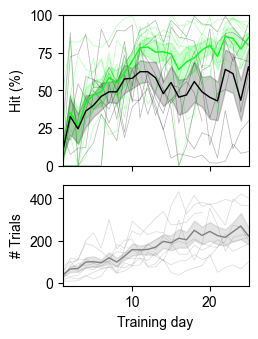

In [37]:
import matplotlib.pyplot as plt

# Ensure 'df_hits' exists and has the columns: mouse, day, percentage_hit_b, percentage_hit_nb, n_trials

fig, (ax, ax_n) = plt.subplots(
    nrows=2, ncols=1, sharex=True,
    figsize=(rm_figsize[0]*2.4, rm_figsize[1]*2.2),
    gridspec_kw={'height_ratios': [1.2, 0.8], 'hspace': 0.15}
)

# Plot each mouse's line (alpha=0.3)
for mouse, df_mouse in df_hits.groupby('mouse'):
    ax.plot(
        df_mouse['day'], df_mouse['percentage_hit_b'], linewidth=0.5,
        color='#00FF0D', alpha=0.3, label='Beaconed' if mouse == df_hits['mouse'].unique()[0] else ""
    )
    ax.plot(
        df_mouse['day'], df_mouse['percentage_hit_nb'], linewidth=0.5,
        color='black', alpha=0.3, label='Non-beaconed' if mouse == df_hits['mouse'].unique()[0] else ""
    )
    ax_n.plot(
        df_mouse['day'], df_mouse['n_trials'], linewidth=0.5,
        color='grey', alpha=0.3
    )

# Calculate mean and SEM across mice for each day
days = np.sort(df_hits['day'].unique())
mean_b = df_hits.groupby('day')['percentage_hit_b'].mean()
sem_b = df_hits.groupby('day')['percentage_hit_b'].sem()
mean_nb = df_hits.groupby('day')['percentage_hit_nb'].mean()
sem_nb = df_hits.groupby('day')['percentage_hit_nb'].sem()
mean_n = df_hits.groupby('day')['n_trials'].mean()
sem_n = df_hits.groupby('day')['n_trials'].sem()

# Plot mean with SEM fill (alpha=1 for mean)
ax.plot(days, mean_b, color='#00FF0D', alpha=1, linewidth=1, label='Beaconed (mean)')
ax.fill_between(days, mean_b - sem_b, mean_b + sem_b, color='#00FF0D', alpha=0.2)

ax.plot(days, mean_nb, color='black', alpha=1, linewidth=1, label='Non-beaconed (mean)')
ax.fill_between(days, mean_nb - sem_nb, mean_nb + sem_nb, color='black', alpha=0.2)

ax.set_ylabel('Hit (%)')
ax.set_ylim(0, 100)
ax.set_yticks([0,25,50,75,100])

# Number of trials per training day (all trial types combined)
ax_n.plot(days, mean_n, color='grey', alpha=1, linewidth=1)
ax_n.fill_between(days, mean_n - sem_n, mean_n + sem_n, color='grey', alpha=0.2)
ax_n.set_xlabel('Training day')
ax_n.set_ylabel('# Trials')
ax_n.set_xlim(1,25)

plt.tight_layout()
base_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_7_behaviour/behaviour_hit_percentage'
plt.savefig(f'{base_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{base_path}.png', dpi=500, bbox_inches='tight')
plt.show()

Processing M20D14...


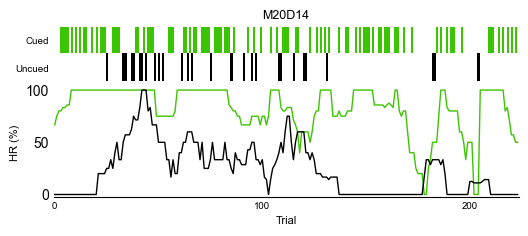

Processing M20D15...


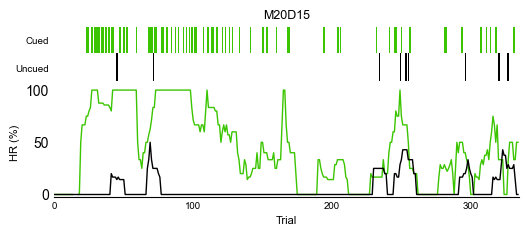

Processing M20D16...


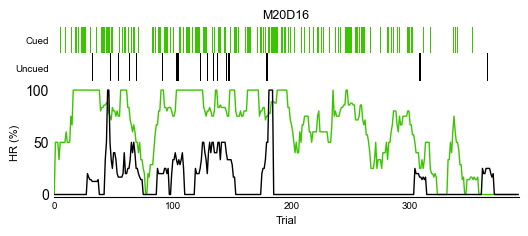

Processing M20D17...


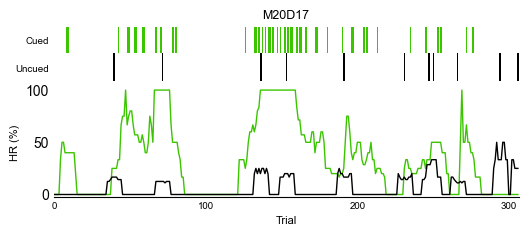

Processing M20D18...


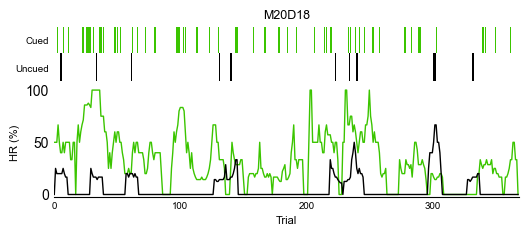

Processing M20D19...


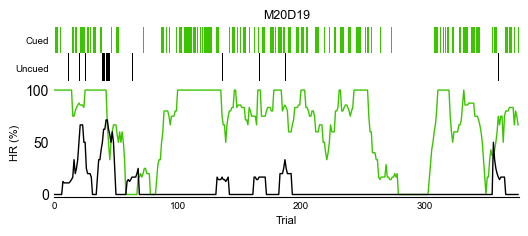

Processing M20D20...


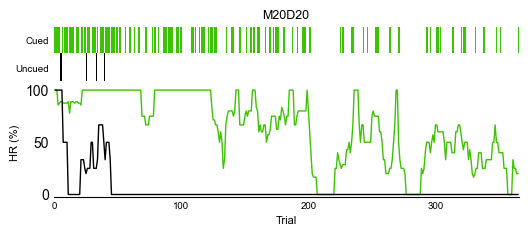

Processing M20D21...


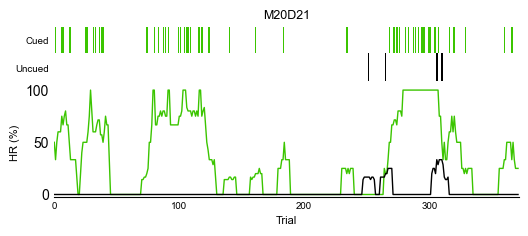

Processing M20D22...


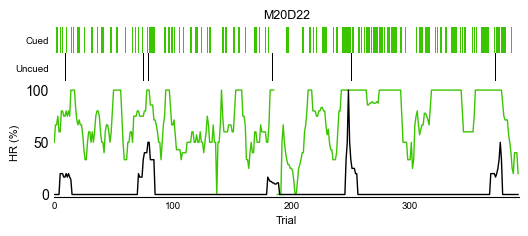

Processing M20D23...


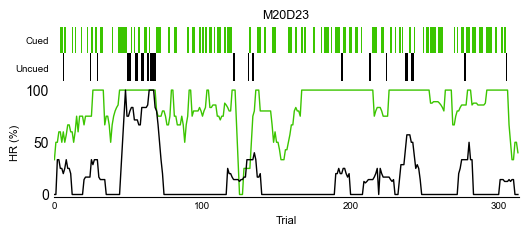

Processing M20D24...


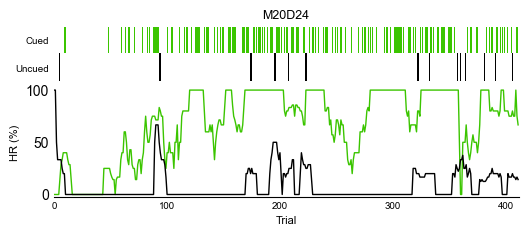

Processing M20D25...


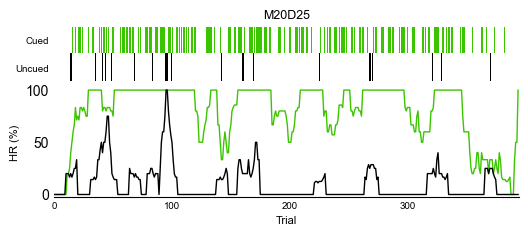

Processing M20D26...


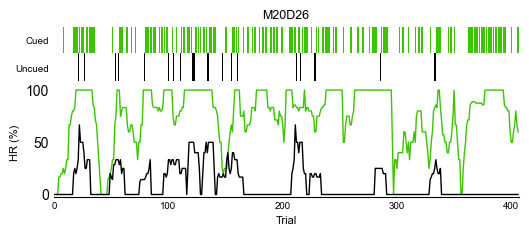

Processing M21D15...


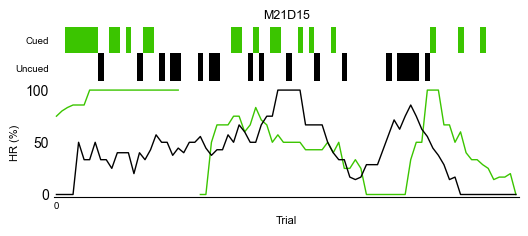

Processing M21D16...


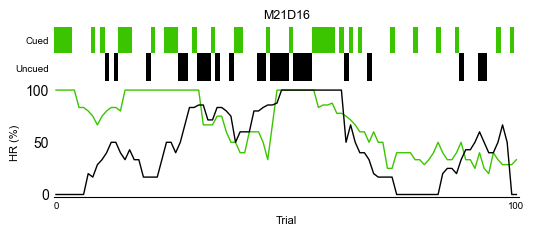

Processing M21D17...


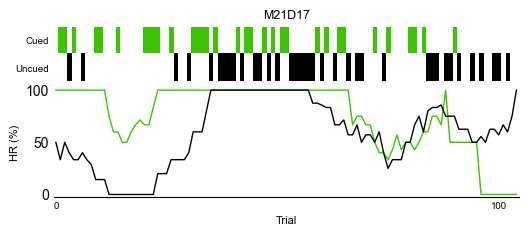

Processing M21D18...


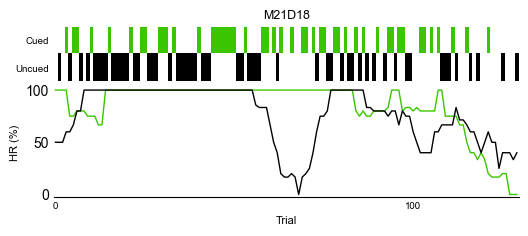

Processing M21D19...


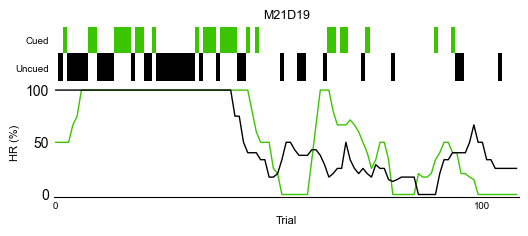

Processing M21D20...


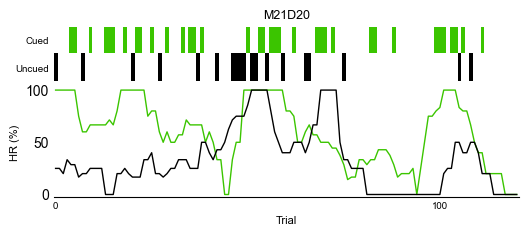

Processing M21D21...


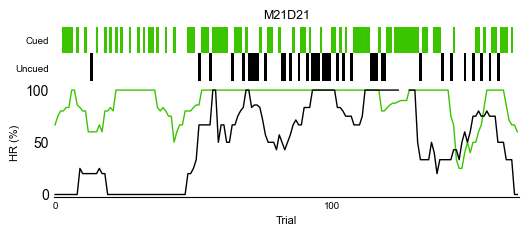

Processing M21D22...


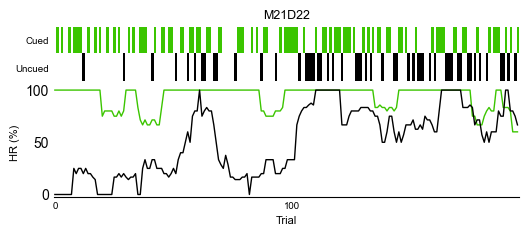

Processing M21D23...


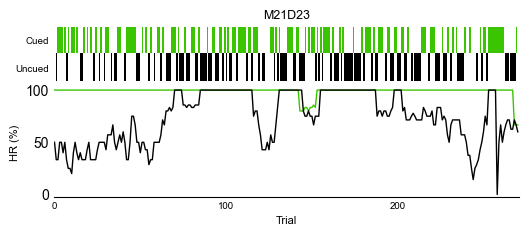

Processing M21D24...


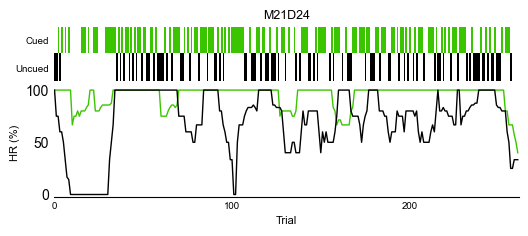

Processing M21D25...


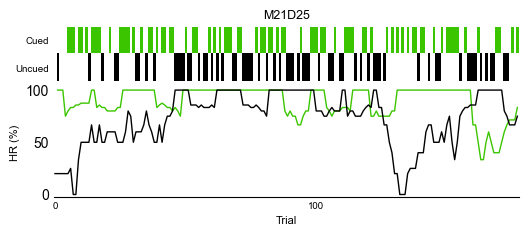

Processing M21D26...


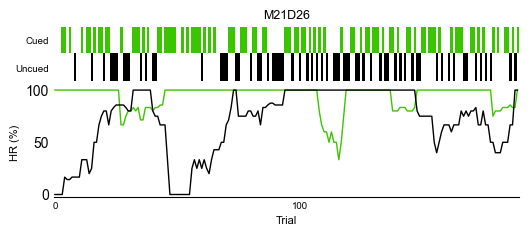

Processing M22D33...


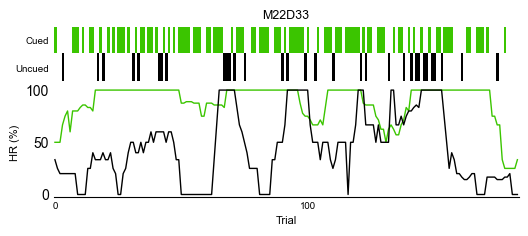

Processing M22D34...


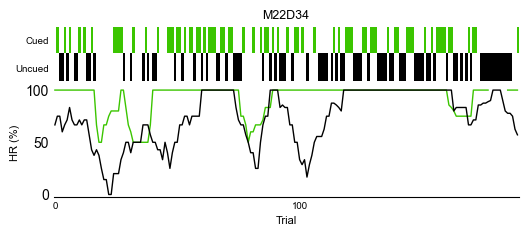

Processing M22D35...


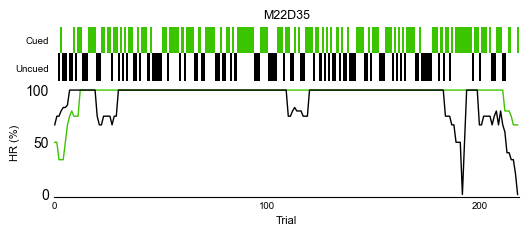

Processing M22D36...


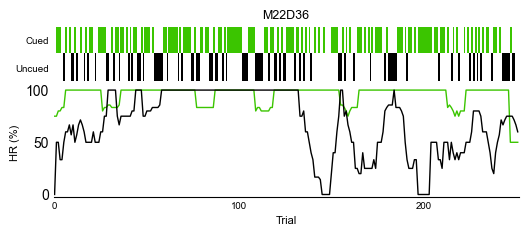

Processing M22D37...


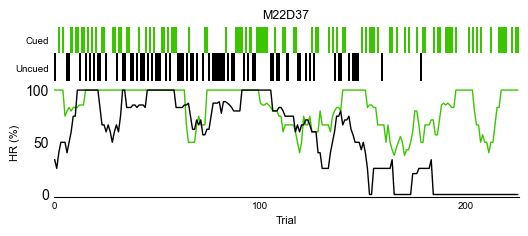

Processing M22D38...


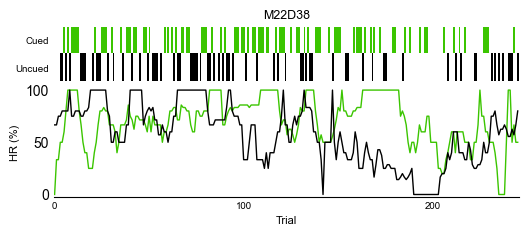

Processing M25D16...


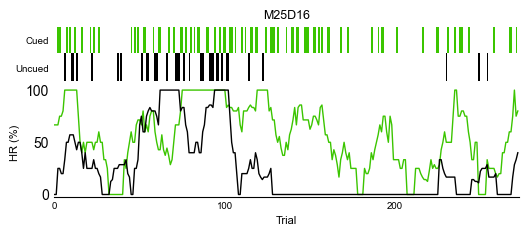

Processing M25D17...


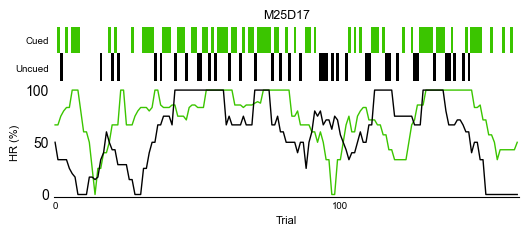

Processing M25D18...


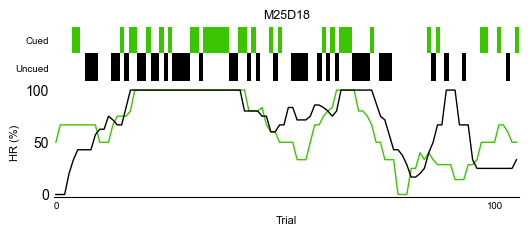

Processing M25D19...


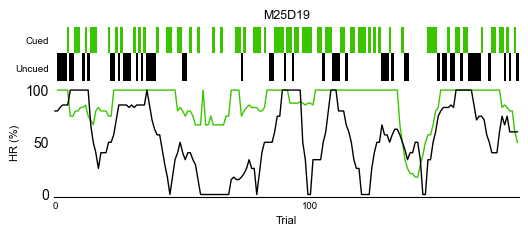

Processing M25D20...


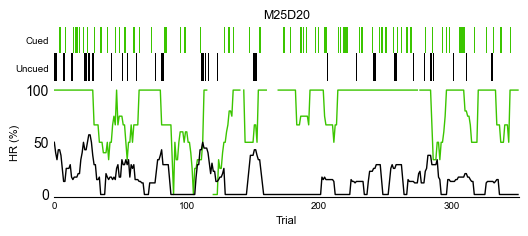

Processing M25D21...


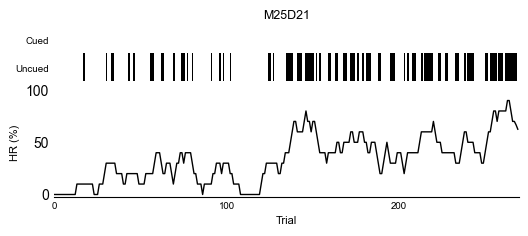

Processing M25D22...


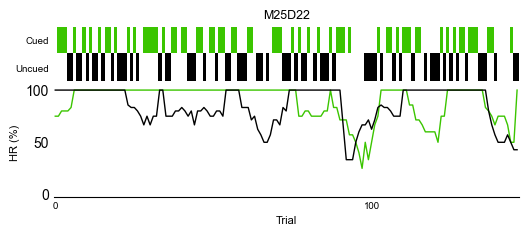

Processing M25D23...


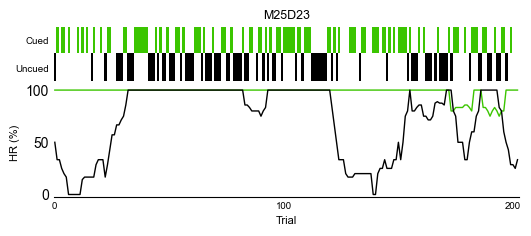

Processing M25D24...


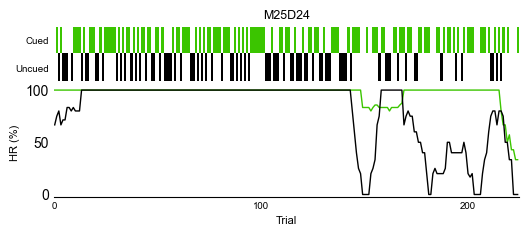

Processing M25D25...


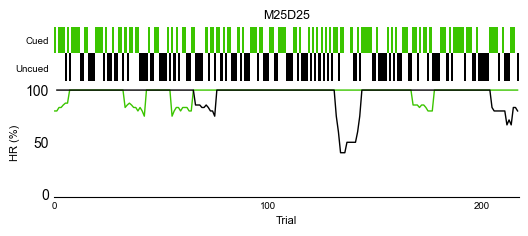

Processing M26D11...


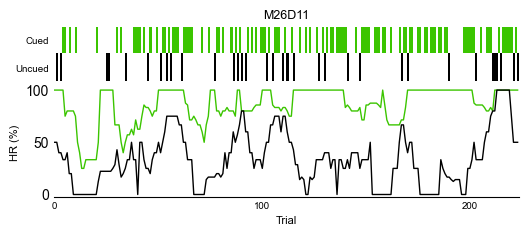

Processing M26D12...


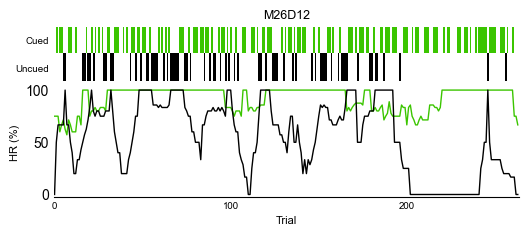

Processing M26D13...


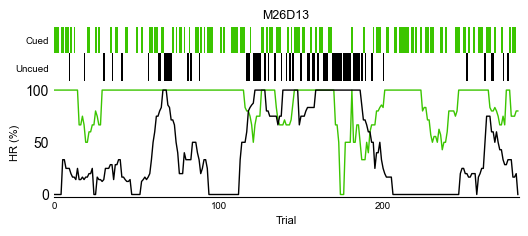

Processing M26D14...


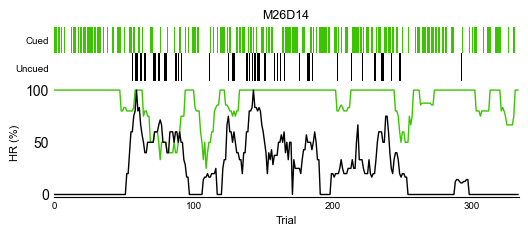

Processing M26D15...


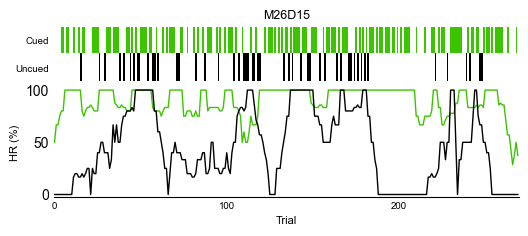

Processing M26D17...


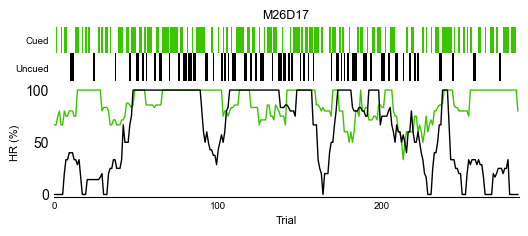

Processing M26D18...


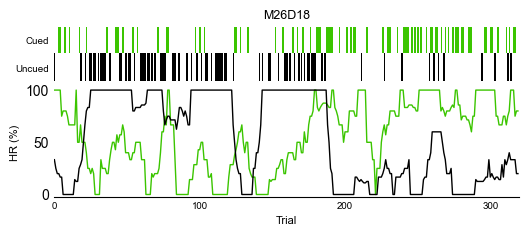

Processing M26D19...


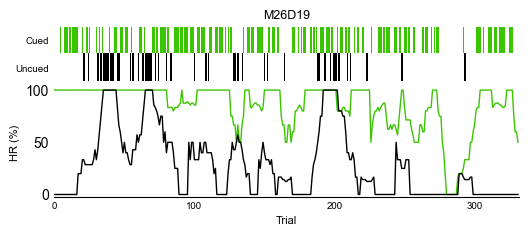

Processing M27D16...


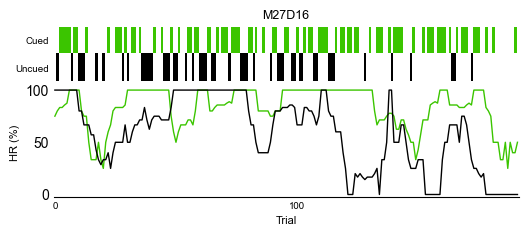

Processing M27D18...


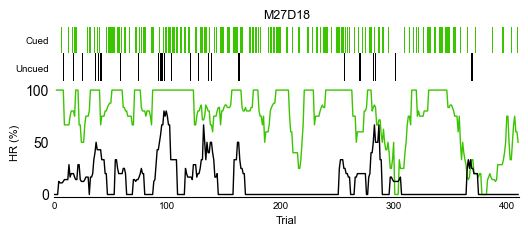

Processing M27D19...


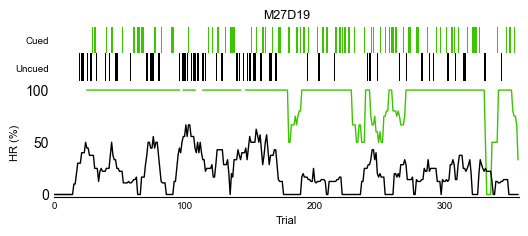

Processing M27D20...


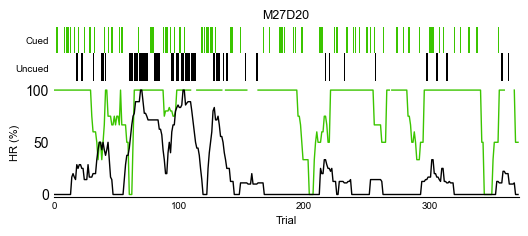

Processing M27D21...


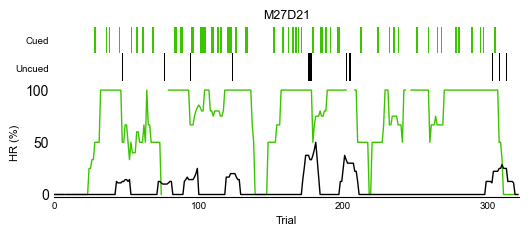

Processing M27D22...


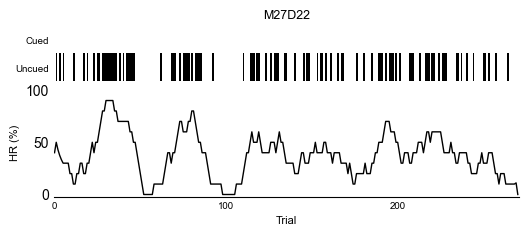

Processing M27D23...


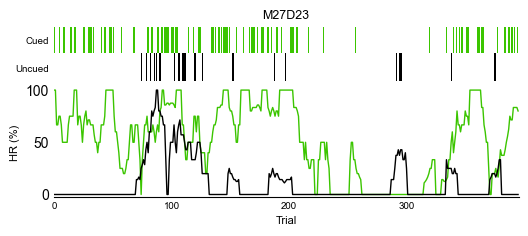

Processing M27D24...


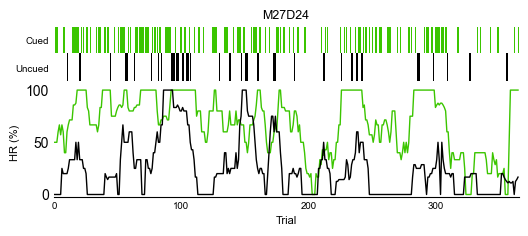

Processing M27D26...


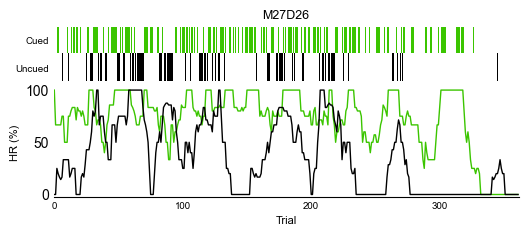

Processing M28D16...


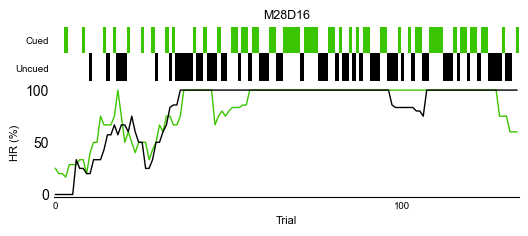

Processing M28D17...


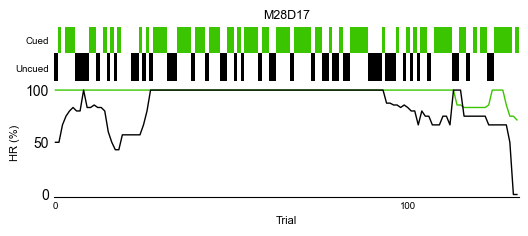

Processing M28D19...


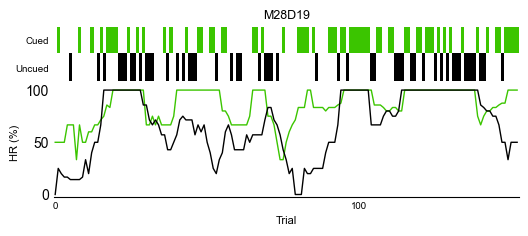

Processing M28D20...


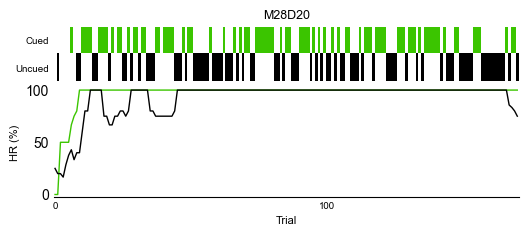

Processing M28D21...


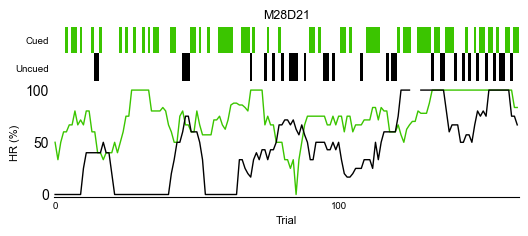

Processing M28D22...


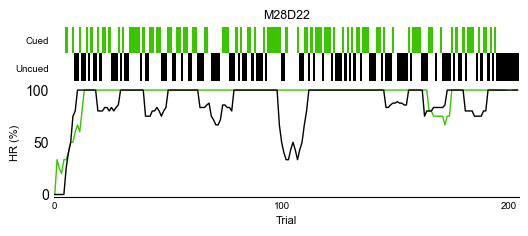

Processing M28D23...


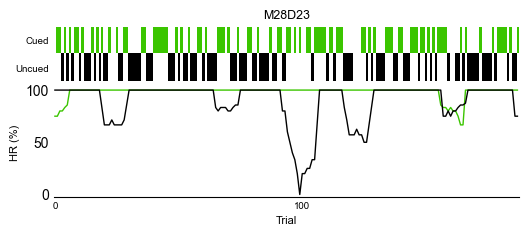

Processing M28D25...


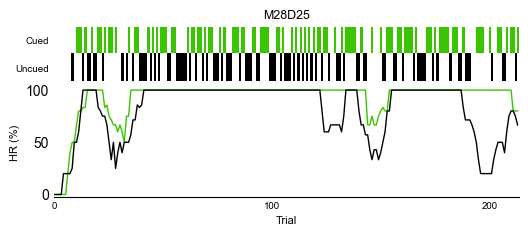

Processing M29D16...


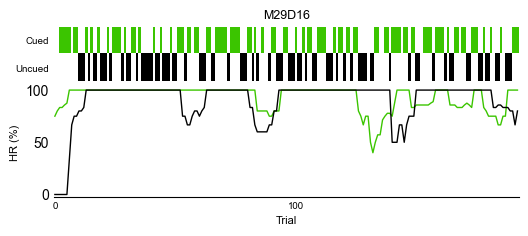

Processing M29D17...


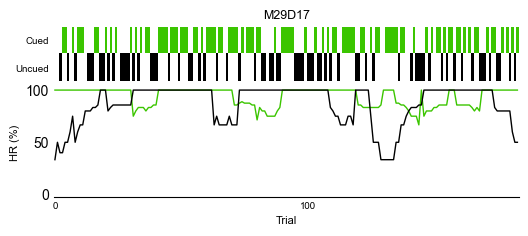

Processing M29D18...


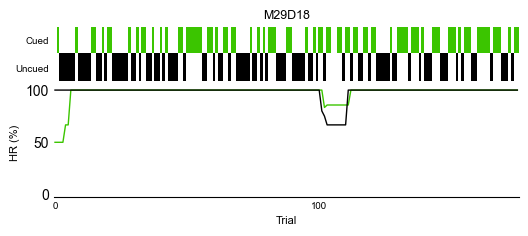

Processing M29D19...


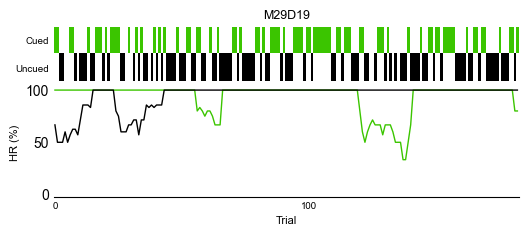

Processing M29D20...


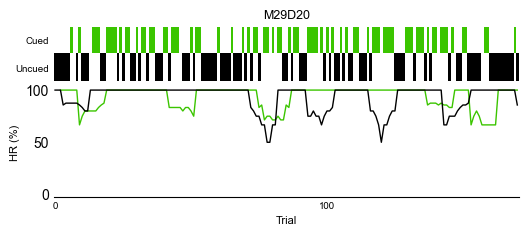

Processing M29D21...


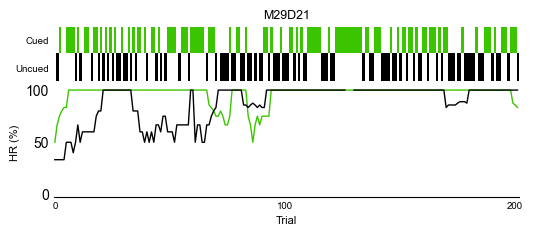

Processing M29D22...


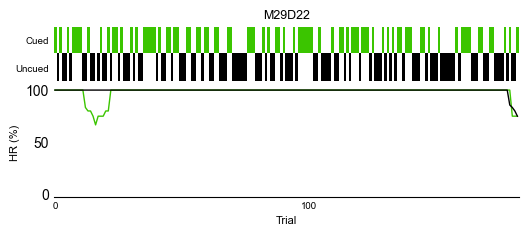

Processing M29D23...


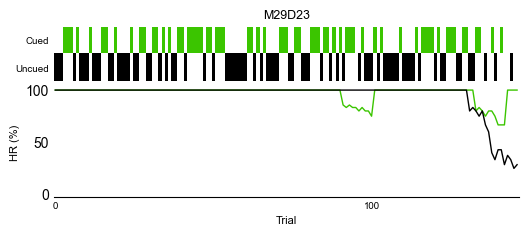

Processing M29D25...


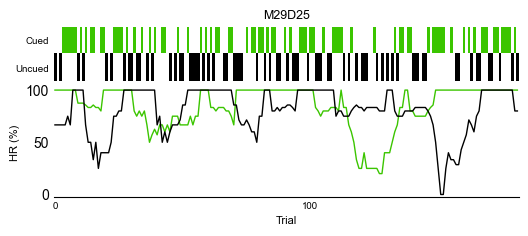

Done.


In [7]:
import os
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── Helpers (not imported in this notebook) ───────────────────────────────────
def _make_hit_mask(beh, trial_types):
    trials = beh['trials']
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]
    type_mask = trials['type'].isin(trial_types)
    hit_mask  = trials['performance'] == 'hit'
    return (type_mask & hit_mask).to_numpy()

def _make_trialtype_mask(beh, trial_types):
    trials = beh['trials']
    if isinstance(trial_types, (str, int)):
        trial_types = [trial_types]
    return trials['type'].isin(trial_types).to_numpy()

# ── All unique sessions from cell_classifications ─────────────────────────────
sessions = sorted(
    cell_classifications[['mouse', 'day']].drop_duplicates().values.tolist()
)
sessions = [(int(m), int(d)) for m, d in sessions]

# ── Shared colour maps ────────────────────────────────────────────────────────
hit_cmap = ListedColormap(["white", "#3bc500", "black"])
hit_norm = BoundaryNorm([0, 0.5, 1.5, 2.5], hit_cmap.N)

# ── Output directory ──────────────────────────────────────────────────────────
out_dir = os.path.join(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures',
    'figure_7_behaviour', 'hit_rate_rasters'
)
os.makedirs(out_dir, exist_ok=True)

window = 10
kernel = np.ones(window) / window

for mouse, day in sessions:
    print(f"Processing M{mouse}D{day}...")
    try:
        _, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
            mouse, day, apply_zscore=False, apply_guassian_filter=False
        )
    except Exception as e:
        print(f"  Skipping M{mouse}D{day}: {e}")
        continue

    max_len = int(last_ephys_bin / (tl / bs))

    nb_hit_mask_s  = _make_hit_mask(beh, 'nb')
    b_hit_mask_s   = _make_hit_mask(beh, 'b')
    nb_type_mask_s = _make_trialtype_mask(beh, 'nb')
    b_type_mask_s  = _make_trialtype_mask(beh,  'b')
    n_use = min(max_len, len(nb_hit_mask_s))

    # ── Hit raster ────────────────────────────────────────────────────────
    hit_raster = np.full((2, max_len), np.nan)
    hit_raster[0, :n_use][b_hit_mask_s[:n_use]]  = 1
    hit_raster[1, :n_use][nb_hit_mask_s[:n_use]] = 1
    hit_raster_plot = np.zeros_like(hit_raster)
    hit_raster_plot[0] = np.where(np.isnan(hit_raster[0]), 0, 1)
    hit_raster_plot[1] = np.where(np.isnan(hit_raster[1]), 0, 2)

    # ── Rolling hit rate ──────────────────────────────────────────────────
    nb_den = np.convolve(nb_type_mask_s.astype(float), kernel, mode='same')
    b_den  = np.convolve(b_type_mask_s.astype(float),  kernel, mode='same')
    nb_r   = np.where(nb_den > 0,
                      np.convolve(nb_hit_mask_s.astype(float), kernel, mode='same') / nb_den * 100,
                      np.nan)
    b_r    = np.where(b_den  > 0,
                      np.convolve(b_hit_mask_s.astype(float),  kernel, mode='same') / b_den  * 100,
                      np.nan)
    nb_rolling = np.full(max_len, np.nan); nb_rolling[:n_use] = nb_r[:n_use]
    b_rolling  = np.full(max_len, np.nan); b_rolling[:n_use]  = b_r[:n_use]

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, (ax_hit, ax_pct) = plt.subplots(
        2, 1, figsize=(6, 2.2), sharex=True,
        gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.08}
    )

    ax_hit.imshow(hit_raster_plot, aspect='auto', cmap=hit_cmap, norm=hit_norm,
                  interpolation='nearest', rasterized=True)
    ax_hit.set_yticks([0, 1])
    ax_hit.set_yticklabels(['Cued', 'Uncued'], fontsize=7)
    ax_hit.set_title(f"M{mouse}D{day}", fontsize=9)
    for sp in ax_hit.spines.values(): sp.set_visible(False)
    ax_hit.tick_params(left=False, bottom=False, labelbottom=False, length=0)

    x = np.arange(max_len)
    ax_pct.plot(x, b_rolling,  color='#3bc500', linewidth=1.0, label='Cued')
    ax_pct.plot(x, nb_rolling, color='black',   linewidth=1.0, label='Uncued')
    ax_pct.set_ylim(-2, 102)
    ax_pct.set_yticks([0, 50, 100])
    ax_pct.set_ylabel('HR (%)', fontsize=8)
    ax_pct.set_xlabel('Trial', fontsize=8)
    for sp in ax_pct.spines.values(): sp.set_visible(False)
    ax_pct.spines['bottom'].set_visible(True)
    ax_pct.tick_params(length=0)
    xticks = list(range(0, max_len + 1, 100))
    ax_pct.set_xticks(xticks)
    ax_pct.set_xticklabels(xticks, fontsize=7)

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'M{mouse}D{day}_hit_rate.pdf'),
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print("Done.")
